In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,calculate_relative_distance_goal_ts,get_initial_turn_direction
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [216]:
test = pd.read_hdf(r"D:\obstacle_avoidance\metadata\obstacle_avoidance_paper\joint.h5")
test1 = pd.read_hdf(r"D:\obstacle_avoidance\metadata\obstacle_avoidance_paper\joint1.h5")
joint = pd.concat([test,test1])
intial_distance_to_obstacle(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)

In [229]:
long_test,short,middle = create_df_by_type(joint)

In [239]:
distance_at_head_turn(long)

[104 132]
[21]
[ 9 22 40 51 61]
[146 179 189 244]
[ 23  68 180 205]
[ 9 36]
[ 14 179 196]
[15 78]
[14 56 78]
[ 2 38 60 74]
[ 6 38]
[ 18  53  67 125]
[ 8 50 65]
[  3  25  45  58 107 136 156 198 247 286 303 314]
[ 4 18 61 72]
[ 12  29 141 165 227 240 330 447]
[ 2 15 62]
[ 13  71  91 111]
[ 2 16 41]
[20 48]
[ 6 31 42 61]
[19 43 64]
[ 5 29 67]
[  8  57 110 156 207 266]
[53 82]
[ 23  92 108]
[115 160 176]
[20 32 58 69]
[ 14  49  66  98 128]
[ 15  35 289]
[ 29  50 137 187]
[14 77]
[31 50 88]
[12 49 75]
[63]
[15 48]
[12 41 51]
[ 9 31]
[39 60 87]
[ 6 53]
[ 9 45 89]
[ 7 27 40 50]
[ 26  69 113 148 185 201]
[12 44 59]
[ 7 24 39]
[14 25]
[17]
[ 12 179 263 289]
[ 3 25 48 75]
[ 5 29 64 74]
[18 61]
[12 30 60 71]
[ 2 20]
[11 44 63]
[  3  30  82 100 127 143]
[33]
[ 8 33]
[ 90 102 149]
[ 20  66  87 112]
[ 28  50  79 129]
[13 28 64]
[ 20  41  67 134 154 212]
[  2  43  64 158 173]
[16 50]
[  8  64  83 100]
[7]
[21 41]
[11]
[17 27 43]
[ 3 13 47]
[12 25 35 50]
[ 10  32  80 100 135]
[ 3 43 61]
[14 37 55 76]


In [259]:
np.where(flatten_list_of_arrays(light.head_angle.to_numpy())>100)

(array([  1071,   1072,   1073, ..., 229355, 236015, 236016], dtype=int64),)

(array([5.30000e+01, 4.40000e+01, 2.67000e+02, 5.67000e+02, 1.02127e+05,
        1.31453e+05, 5.48000e+02, 1.38000e+02, 4.70000e+01, 4.80000e+01]),
 array([-4485.87840806, -3593.83792978, -2701.79745149, -1809.75697321,
         -917.71649493,   -25.67601664,   866.36446164,  1758.40493992,
         2650.44541821,  3542.48589649,  4434.52637477]),
 <BarContainer object of 10 artists>)

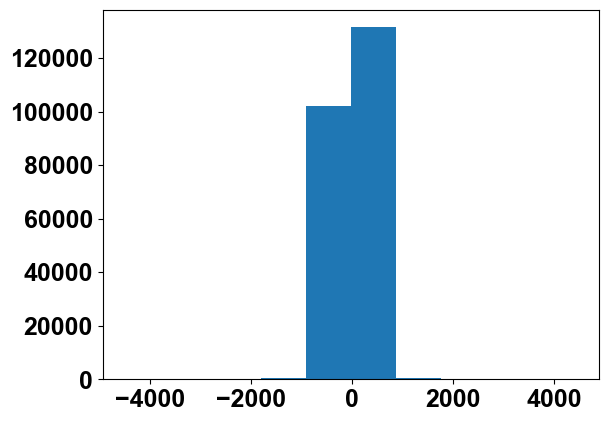

In [263]:
plt.hist(flatten_list_of_arrays(light.head_angle_velocity.to_numpy())*60)

(array([0.        , 0.        , 0.00691183, 0.00491232, 0.00312657,
        0.00206534, 0.00130677, 0.0008505 , 0.00050281, 0.00032386]),
 array([  0.,  50., 100., 150., 200., 250., 300., 350., 400., 450., 500.]),
 <BarContainer object of 10 artists>)

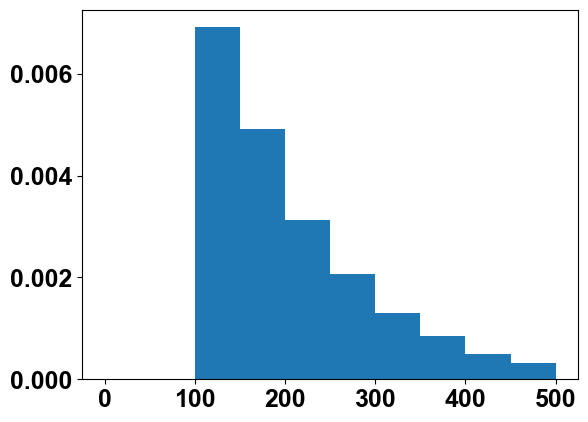

In [267]:
plt.hist(flatten_list_of_arrays(light.head_angle_velocity.to_numpy()*60)[np.where(flatten_list_of_arrays(light.head_angle_velocity.to_numpy()*60)>100)],range = (0,500),density=True)

In [236]:
head_angle_velocity(long)

In [23]:
test = long.sample(1)
test.num_turn

3192    5.0
Name: num_turn, dtype: float64

In [13]:
list_columns(test,['velocity'])

array(['head_angle_velocity', 'head_corner_angle_velocity',
       'intial_head_angle_velocity',
       'head_corner_angle_velocity_at_head_turn', 'head_turn_velocity'],
      dtype='<U39')

In [ ]:
for ind,row in test.iterrows():


peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(4,20),distance=10)

In [237]:
long.num_turn

8        2.0
17       0.0
24       4.0
27       2.0
29       3.0
        ... 
14456    2.0
14459    0.0
14479    0.0
14481    2.0
14523    0.0
Name: num_turn, Length: 3407, dtype: float64

In [230]:
long_test.loc[[14523]]

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,distance_at_head_turn_2_indexs,angle_at_head_turn_2,num_turn,towards_num_turn,away_num_turn,right_num_turn,right_turns_distances,left_num_turn,left_turns_distances,intial_distance
14523,14523,55826.575206,55829.250214,"[55826.587891, 55826.604531, 55826.622195, 558...","[8848, 8849, 8850, 8851, 8852, 8853, 8854, 885...","[89.8214340209961, 89.41398620605469, 89.51441...","[264.9470520019531, 264.7117004394531, 265.335...","[96.99906158447266, 95.96925354003906, 95.4502...","[263.537841796875, 263.6693420410156, 263.7026...","[98.167724609375, 97.40418243408203, 97.049728...",...,"[3, 18, 31]",61.030811,3.0,0.0,NaN,3.0,"[16.690404931029303, 9.2535297136081, 3.296641...",0.0,[],18.0


In [474]:
test

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,indexs_of_head_turn,head_turn_indexs,before_head_turn_indexs,after_head_turn_indexs,angle_after_head_turn,angle_before_head_turn,head_turn_velocity,angles_at_head_turns,distances_at_head_turns,angles_at_head_turns_ends
9743,9743,48968.3504,48972.807129,"[48968.355788, 48968.372377, 48968.389196, 489...","[[27138, 27139, 27140, 27141, 27142, 27143, 27...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[664.2531127929688, 664.9830932617188, 666.037...","[238.9049530029297, 239.87796020507812, 240.39...","[662.1133422851562, 663.8797607421875, 665.256...",...,"[87, 90, 92]","[2, 18, 31, 66, 77, 90, 104]","[1, 15, 27, 63, 75, 87, 102]","[5, 21, 34, 69, 80, 92, 109]",91.626212,156.273057,12.088437,"[81.17802391399114, 88.85838559710892, 154.839...","[22.430567049858922, 16.841685231633228, 19.89...","[67.16036003910897, 110.7127391994439, 173.729..."


[ 7 22 37]


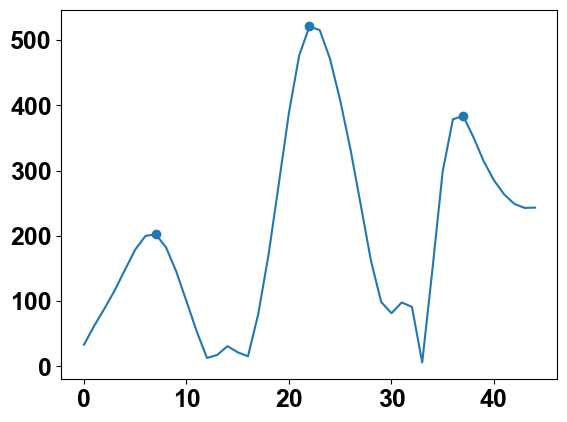

In [485]:
test = long.sample(1)
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]),width=2,distance=5) 
    plt.plot(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])*60) 
    plt.scatter(peaks,(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])*60)[peaks])  
    print(peaks)

1
oa


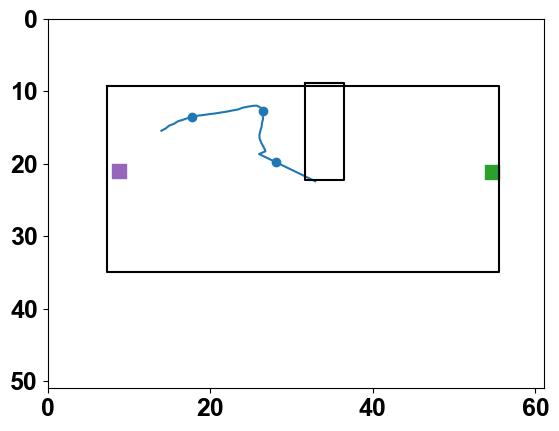

In [486]:
fig,ax = plt.subplots()
ax.plot(row.ts_nose_x_cm[:int(row.obstacle_ind)],row.ts_nose_y_cm[:int(row.obstacle_ind)])
ax.scatter(row.ts_nose_x_cm[peaks],row.ts_nose_y_cm[peaks])
plot_arena(test,ax)
plot_orginal_obstacle(test,ax,row.obstacle_cluster)
print(row.obstacle_cluster)
print(row.task)

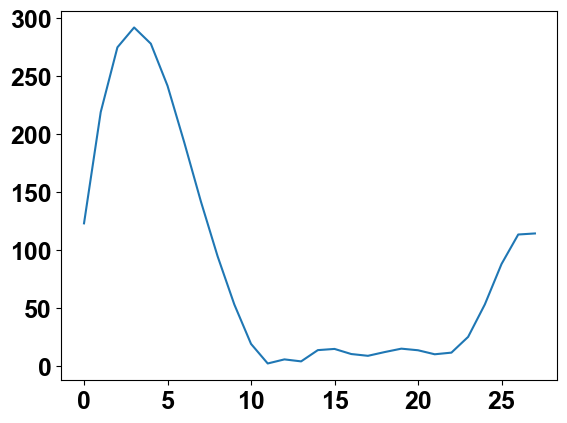

In [270]:
for ind,row in test.sample(1).iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(4,20),distance=10) 
    plt.plot(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])*60)   

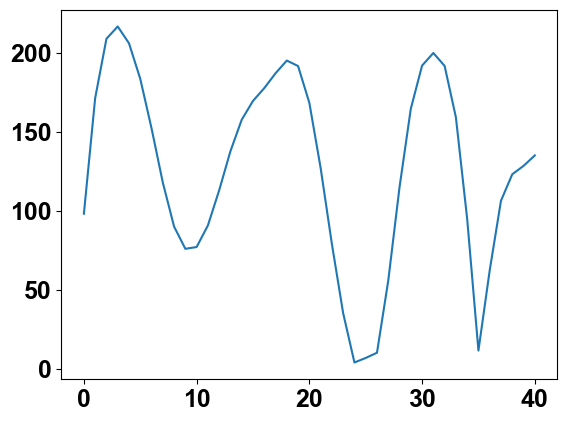

In [268]:
for ind,row in long_test.loc[[14523]].iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(4,20),distance=10) 
    plt.plot(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])*60)   

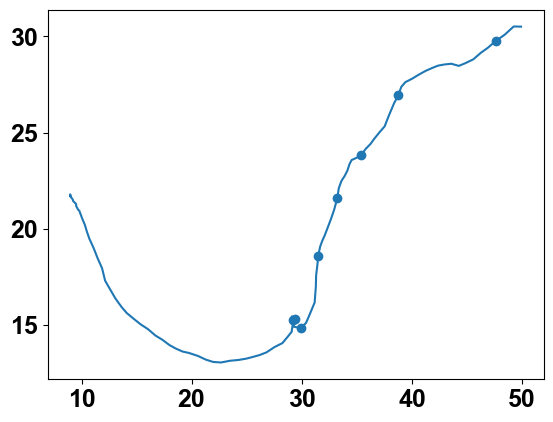

In [367]:
plt.plot(row.ts_nose_x_cm,row.ts_nose_y_cm)
plt.scatter(row.ts_nose_x_cm[peaks],row.ts_nose_y_cm[peaks])

In [232]:
peaks

array([], dtype=int64)

In [241]:
long.loc[[14523]]

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,indexs_of_head_turn,head_turn_indexs,before_head_turn_indexs,after_head_turn_indexs,angle_after_head_turn,angle_before_head_turn,head_turn_velocity,angles_at_head_turns,distances_at_head_turns,angles_at_head_turns_ends
14523,14523,55826.575206,55829.250214,"[55826.587891, 55826.604531, 55826.622195, 558...","[8848, 8849, 8850, 8851, 8852, 8853, 8854, 885...","[89.8214340209961, 89.41398620605469, 89.51441...","[264.9470520019531, 264.7117004394531, 265.335...","[96.99906158447266, 95.96925354003906, 95.4502...","[263.537841796875, 263.6693420410156, 263.7026...","[98.167724609375, 97.40418243408203, 97.049728...",...,"[1, 3, 6]","[3, 18, 31]","[1, 13, 28]","[6, 21, 34]",55.04783,71.579236,3.607684,"[42.67403294416877, 30.02058485748855]","[9.2535297136081, 3.2966418565880566]","[32.89857310991093, 15.76073845537379]"


In [228]:
distance_at_head_turn(long.loc[[14523]])

[]


In [225]:
long.loc[[14523]].head_angle_velocity

14523    [1.6347577660386703, 2.8529514558113167, 3.478...
Name: head_angle_velocity, dtype: object

In [218]:
long

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,distance_at_head_turn_2_indexs,angle_at_head_turn_2,num_turn,towards_num_turn,away_num_turn,right_num_turn,right_turns_distances,left_num_turn,left_turns_distances,intial_distance
8,8,48098.019340,48102.816128,"[48098.031385, 48098.048576, 48098.06464, 4809...","[[3308, 3309, 3310, 3311, 3312, 3313, 3314, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9629516601562, 650.8632202148438, 650.746...","[252.6468963623047, 251.91566467285156, 251.48...","[656.01318359375, 656.386474609375, 656.445373...",...,"[104, 132, 139]",50.385093,3.0,0.0,NaN,1.0,[2.3336543876011326],2.0,"[1.8804369365781402, 1.8904238936934148]",25.0
17,17,48338.593881,48344.042022,"[48338.598041, 48338.614617, 48338.631424, 483...","[[17737, 17738, 17739, 17740, 17741, 17742, 17...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.9925537109375, 652.1788330078125, 652.823...","[254.21148681640625, 254.0948028564453, 254.07...","[656.2599487304688, 657.4254150390625, 658.723...",...,[21],67.816385,1.0,3.0,2.0,1.0,[21.448106895216092],0.0,[],23.0
24,24,48420.115289,48424.506713,"[48420.126092, 48420.143462, 48420.159539, 484...","[[22627, 22628, 22629, 22630, 22631, 22632, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6133422851562, 648.2860107421875, 648.863...","[258.9119873046875, 258.0534973144531, 257.625...","[656.2706298828125, 656.6029052734375, 656.868...",...,"[9, 22, 40, 51, 61]",42.927215,5.0,1.0,3.0,3.0,"[19.126954831503788, 12.68730852308991, 4.2751...",2.0,"[6.2272710475092765, 2.4417895280408155]",23.0
27,27,48451.833305,48459.674124,"[48451.837196, 48451.85399, 48451.870681, 4845...","[[24529, 24530, 24531, 24532, 24533, 24534, 24...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6234741210938, 647.111083984375, 647.8052...","[258.09979248046875, 256.70001220703125, 256.1...","[653.6805419921875, 654.243408203125, 654.8812...",...,"[146, 179, 189, 244]",49.631036,4.0,0.0,NaN,3.0,"[22.825084479564573, 9.934737689725033, 10.338...",1.0,[4.659622630986767],25.0
29,29,48467.768192,48473.544102,"[48467.77591, 48467.792857, 48467.810598, 4846...","[[25485, 25486, 25487, 25488, 25489, 25490, 25...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.9254150390625, 652.91552734375, 653.34338...","[251.62893676757812, 252.2069091796875, 252.18...","[655.7667236328125, 656.9116821289062, 658.112...",...,"[23, 68, 188, 205]",25.765737,4.0,4.0,4.0,2.0,"[22.689007941167716, 2.239520390798571]",2.0,"[4.286593988791843, 2.311305803187799]",25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14456,14456,58284.241510,58286.769433,"[58284.250803, 58284.267686, 58284.284518, 582...","[10663, 10664, 10665, 10666, 10667, 10668, 106...","[87.75959014892578, 86.99541473388672, 86.5253...","[260.9606018066406, 261.192138671875, 260.8676...","[101.29974365234375, 99.75284576416016, 98.431...","[256.0437316894531, 256.8573913574219, 257.122...","[94.1467056274414, 93.94309997558594, 93.60278...",...,"[3, 28, 40]",60.400656,3.0,0.0,NaN,2.0,"[15.944640593180358, 1.3973388914592348]",1.0,[1.3993026260734704],18.0
14459,14459,58310.359923,58312.854592,"[58310.360256, 58310.376601, 58310.39406, 5831...","[12229, 12230, 12231, 12232, 12233, 12234, 122...","[86.841064453125, 86.9388427734375, 86.4898529...","[257.9836730957031, 258.0146179199219, 257.881...","[104.91130065917969, 103.79759979248047, 102.6...","[253.5960235595703, 253.80740356445312, 254.47...","[93.63558959960938, 92.92048645019531, 92.4770...",...,"[20, 30]",62.038556,2.0,1.0,1.0,2.0,"[3.8419081699484536, 1.1020079959351747]",0.0,[],17.0
1

In [217]:
np.where(long.num_turn.to_numpy()==0)[0].shape

(14,)

In [240]:
np.where(long.num_turn.to_numpy()==0)[0].shape

(749,)

In [ ]:
np.iszero(arr).sum()

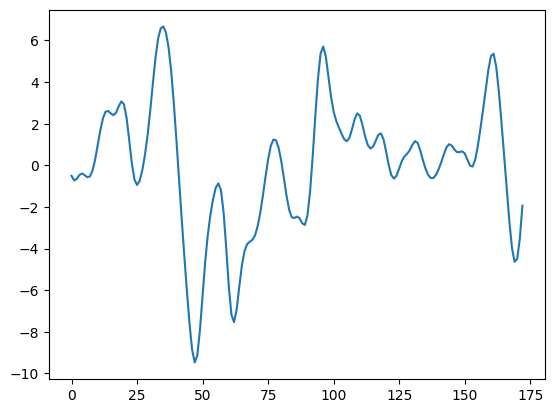

In [24]:
plt.plot(test.head_angle_velocity.to_numpy()[0])

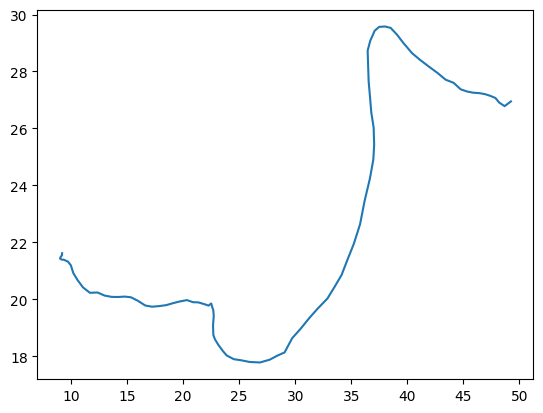

In [20]:
plt.plot(test.ts_nose_x_cm.to_numpy()[0],test.ts_nose_y_cm.to_numpy()[0])

In [26]:
for ind,row in test.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(4,20),distance=10)        

In [40]:
max_peak = peaks[prop['peak_heights'].argmax()]
max_vel = prop['peak_heights'].max()
max_ind = prop['peak_heights'].argmax()
mask = np.ones_like(peaks, dtype=bool)
mask[max_ind] = False 
non_peak_turns_inds =mask
np.round(prop['right_ips'][non_peak_turns_inds]).astype(int)

array([39, 66, 99])

In [ ]:
non_peak_turns_inds =peaks[mask]


array([35, 62, 96], dtype=int64)

In [ ]:
non_peak_turns_inds =peaks[mask]


1

In [31]:
peaks

array([35, 47, 62, 96], dtype=int64)

In [33]:
prop['peak_heights']

array([6.67351355, 9.47644905, 7.53693638, 5.71281607])

In [35]:
peaks

array([35, 47, 62, 96], dtype=int64)

In [37]:
np.where(peaks ==peaks[max_ind] )

(array([1], dtype=int64),)

In [34]:
peaks[max_ind]

47

In [167]:
distance_at_head_turn(long)

In [49]:
test

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,distance_before_head_turn,indexs_of_head_turn,head_turn_indexs,before_head_turn_indexs,after_head_turn_indexs,angle_after_head_turn,angle_before_head_turn,head_turn_velocity,angles_at_head_turns,angles_at_head_turns_ends
3192,3192,53175.897228,53179.469376,"[53175.905664, 53175.923443, 53175.938956, 531...","[18955, 18956, 18957, 18958, 18959, 18960, 189...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[125.09213256835938, 124.2333984375, 123.44226...","[279.6708984375, 278.9678039550781, 278.580108...","[132.19265747070312, 130.8024139404297, 130.21...",...,22.141346,"[43, 47, 51]","[35, 47, 62, 96]","[31, 43, 59, 93]","[39, 51, 66, 99]",56.718076,121.815335,9.476449,"[92.90871598514158, 26.926804673600234, 48.453...","[120.93432229661084, 0.24698291187352742, 29.2..."


In [51]:
test.num_turn

3192    4.0
Name: num_turn, dtype: float64

In [ ]:
test.angles_at_head_turns.to_numpy()

array([array([92.90871598514158, 26.926804673600234, 48.45318725498835],
             dtype=object)                                              ],
      dtype=object)

In [ ]:
plt.plot(test.)


,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,distance_before_head_turn,indexs_of_head_turn,head_turn_indexs,before_head_turn_indexs,after_head_turn_indexs,angle_after_head_turn,angle_before_head_turn,head_turn_velocity,angles_at_head_turns,angles_at_head_turns_ends
5164,5164,43944.304806,43946.819955,"[43944.316032, 43944.332646, 43944.349376, 439...","[[16877, 16878, 16879, 16880, 16881, 16882, 16...","[690.6671752929688, nan, nan, nan, nan, nan, n...","[269.2569885253906, nan, nan, nan, nan, nan, n...","[684.7566528320312, 684.9572143554688, 685.897...","[257.53338623046875, 257.49639892578125, 257.9...","[681.2899780273438, 682.6829833984375, 683.756...",...,9.277892,"[20, 24, 28]",[24],[20],[28],7.6954,54.021609,8.487159,26.730846,7.6954


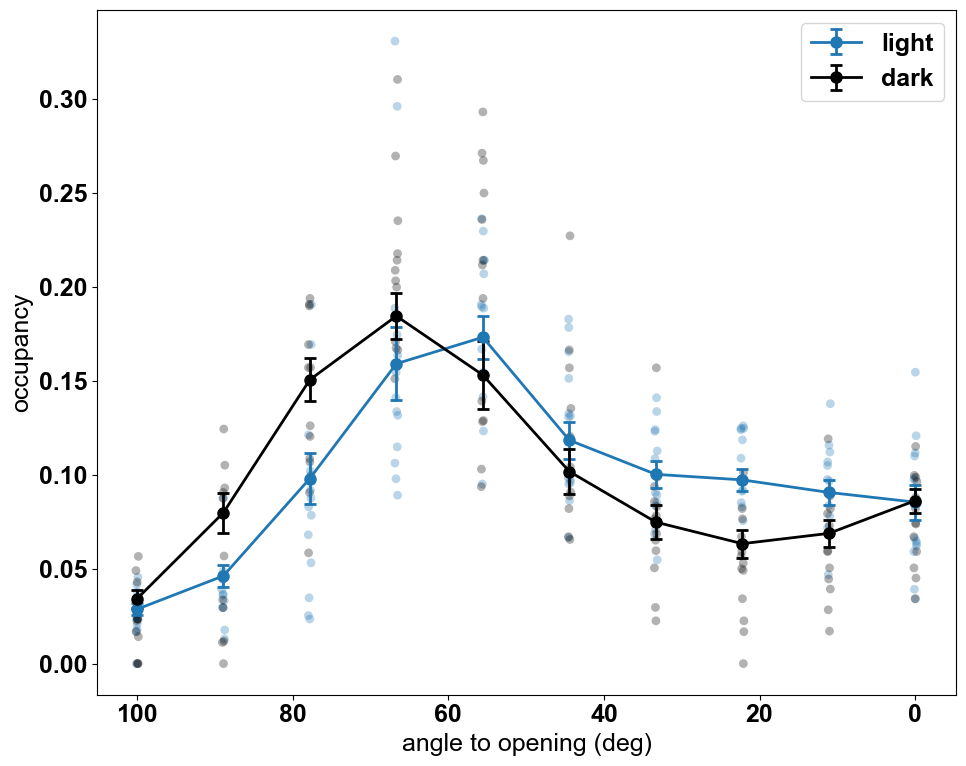

In [242]:
xnew = np.linspace(0, 100, 10)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = flatten_list_of_arrays(light.angles_at_head_turns.to_numpy())
light_dist = light_dist[~np.isnan(light_dist)]
light_counts, light_bins = np.histogram(light_dist,range=(0,100),bins=10)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.angles_at_head_turns.to_numpy())
    ani_light_dists = ani_light_dists[~np.isnan(ani_light_dists)]
    counts, bins = np.histogram(ani_light_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(len(light_prob))  # Changed to SEM

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.angles_at_head_turns.to_numpy())
dark_dist = dark_dist[~np.isnan(dark_dist)]
dark_counts, dark_bins = np.histogram(dark_dist,range=(0,100),bins=10)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.angles_at_head_turns.to_numpy())
    ani_dark_dists = ani_dark_dists[~np.isnan(ani_dark_dists)]
    
    counts, bins = np.histogram(ani_dark_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(len(dark_prob))  # Changed to SEM

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (now using SEM)
ax.errorbar(xnew, light_hist, yerr=light_sem,  # Changed to light_sem
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,  # Changed to dark_sem
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_ylabel('occupancy', fontsize=18)
ax.set_xlabel('angle to opening (deg)', fontsize=18)
ax.invert_xaxis()

# Legend
ax.legend(loc='upper right', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

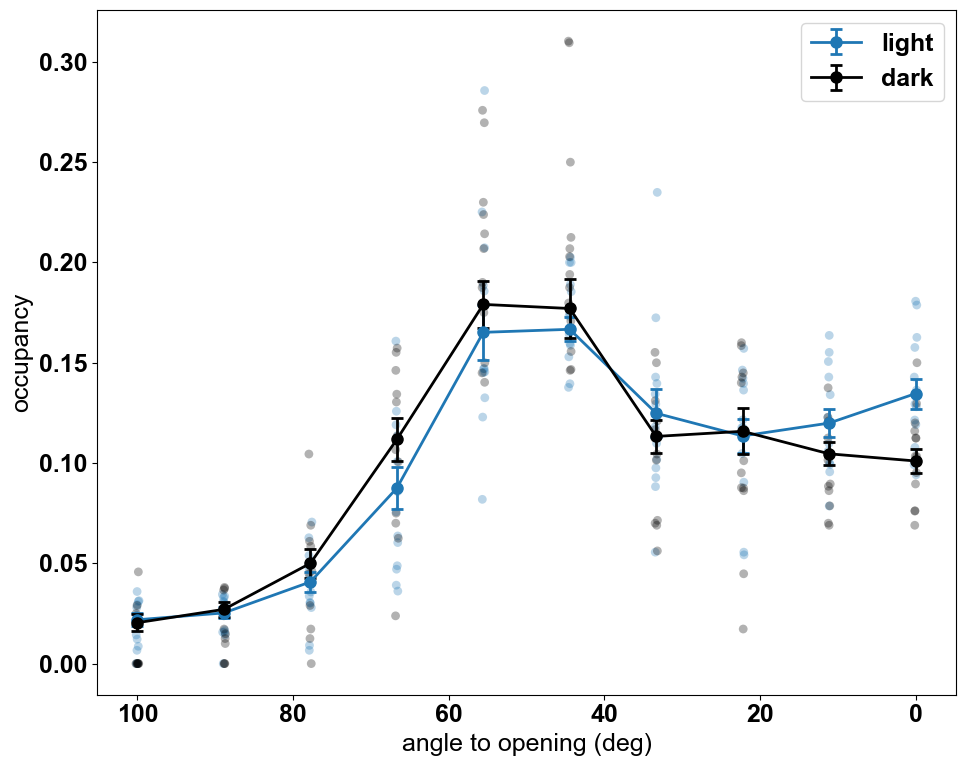

In [243]:
xnew = np.linspace(0, 100, 10)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = flatten_list_of_arrays(light.angles_at_head_turns_ends.to_numpy())
light_dist = light_dist[~np.isnan(light_dist)]
light_counts, light_bins = np.histogram(light_dist,range=(0,100),bins=10)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.angles_at_head_turns_ends.to_numpy())
    ani_light_dists = ani_light_dists[~np.isnan(ani_light_dists)]
    counts, bins = np.histogram(ani_light_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(len(light_prob))  # Changed to SEM

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.angles_at_head_turns_ends.to_numpy())
dark_dist = dark_dist[~np.isnan(dark_dist)]
dark_counts, dark_bins = np.histogram(dark_dist,range=(0,100),bins=10)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.angles_at_head_turns_ends.to_numpy())
    ani_dark_dists = ani_dark_dists[~np.isnan(ani_dark_dists)]
    
    counts, bins = np.histogram(ani_dark_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(len(dark_prob))  # Changed to SEM

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (now using SEM)
ax.errorbar(xnew, light_hist, yerr=light_sem,  # Changed to light_sem
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,  # Changed to dark_sem
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_ylabel('occupancy', fontsize=18)
ax.set_xlabel('angle to opening (deg)', fontsize=18)
ax.invert_xaxis()

# Legend
ax.legend(loc='upper right', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

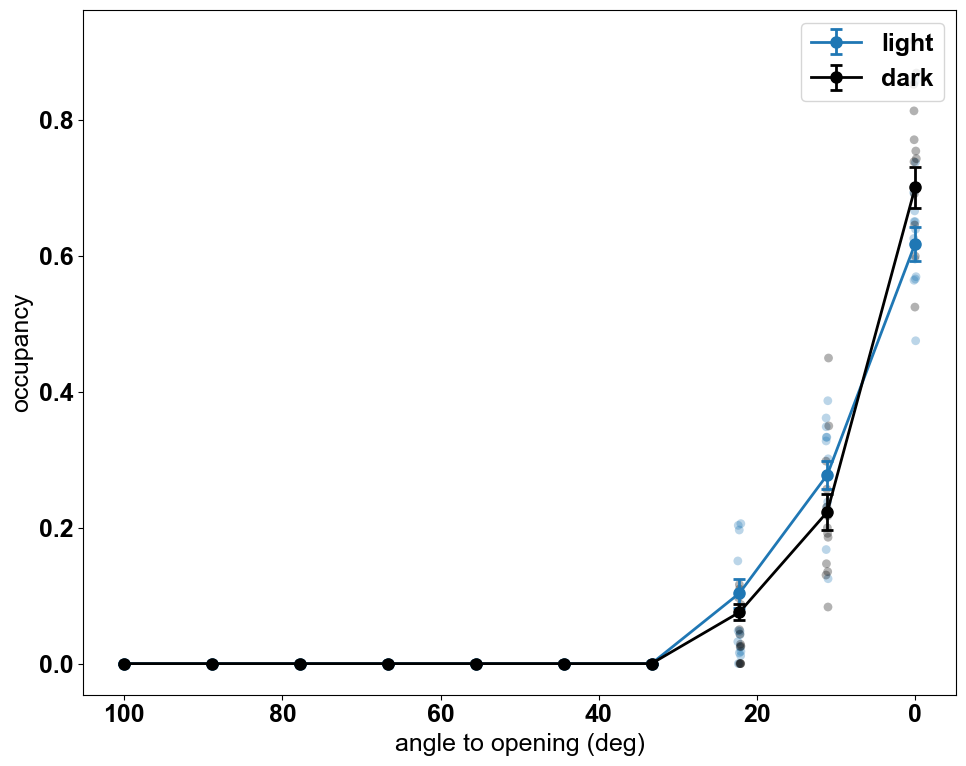

In [68]:
xnew = np.linspace(0, 100, 10)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.distance_after_head_turn.to_numpy())
light_dist = light_dist[~np.isnan(light_dist)]
light_counts, light_bins = np.histogram(light_dist,range=(0,100),bins=10)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.distance_after_head_turn.to_numpy())
    ani_light_dists = ani_light_dists[~np.isnan(ani_light_dists)]
    counts, bins = np.histogram(ani_light_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(len(light_prob))  # Changed to SEM

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.distance_after_head_turn.to_numpy())
dark_dist = dark_dist[~np.isnan(dark_dist)]
dark_counts, dark_bins = np.histogram(dark_dist,range=(0,100),bins=10)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.distance_after_head_turn.to_numpy())
    ani_dark_dists = ani_dark_dists[~np.isnan(ani_dark_dists)]
    
    counts, bins = np.histogram(ani_dark_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(len(dark_prob))  # Changed to SEM

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (now using SEM)
ax.errorbar(xnew, light_hist, yerr=light_sem,  # Changed to light_sem
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,  # Changed to dark_sem
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_ylabel('occupancy', fontsize=18)
ax.set_xlabel('angle to opening (deg)', fontsize=18)
ax.invert_xaxis()

# Legend
ax.legend(loc='upper right', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

In [94]:
dark.angle_after_head_turn.median()

25.445814877482434

<AxesSubplot: >

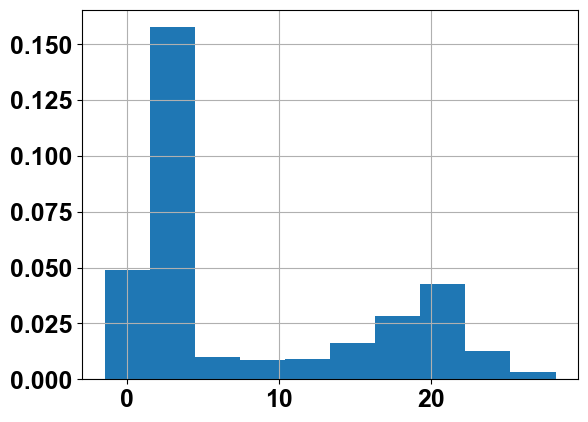

In [244]:
dark.distance_at_head_turn.hist(density=True)

<AxesSubplot: >

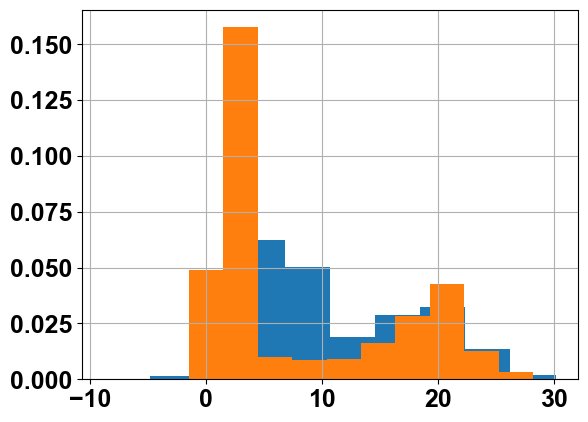

In [245]:
light.distance_at_head_turn.hist(density=True)
dark.distance_at_head_turn.hist(density=True)

In [106]:
light_dist

array([2.33365439,        nan, 4.27514921, ...,        nan,        nan,
              nan])

In [ ]:
drop_nans_in_columns

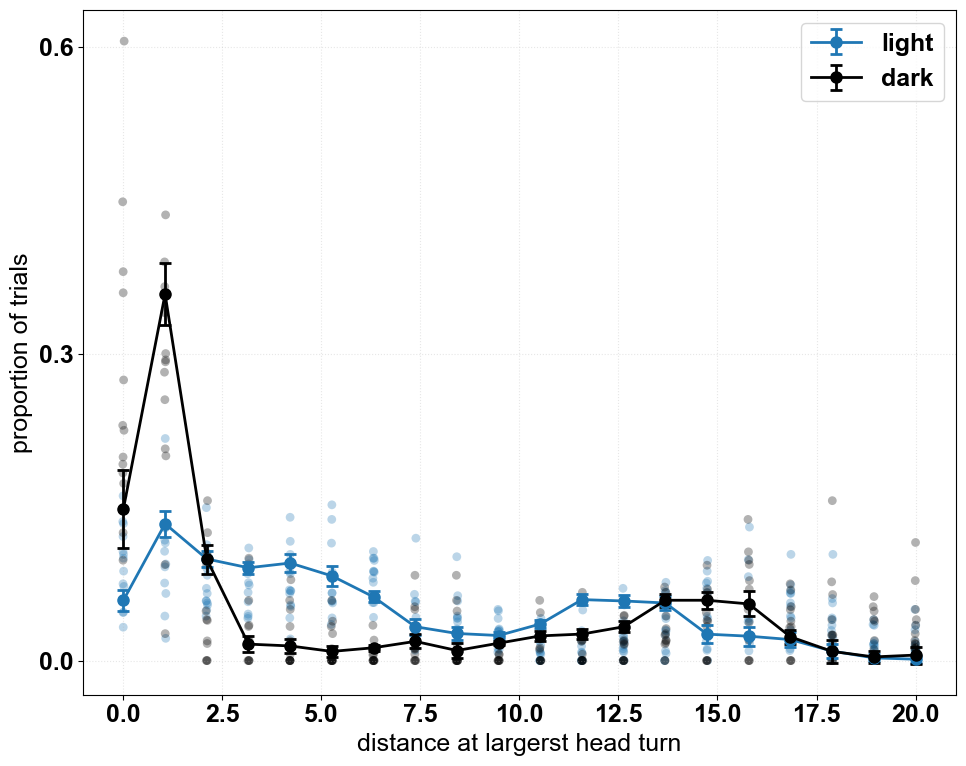

In [246]:
xnew = np.linspace(0, 20, 20)
data = pd.concat([long])
#data = data[data.turn_to_obstacle == 'towards']
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light = drop_nans_in_columns(light,['distance_at_head_turn'])
light_dist = (light.distance_at_head_turn.to_numpy())
light_dist = light_dist[np.where((light_dist >0))]
light_counts, light_bins = np.histogram(light_dist, bins=20)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >0))]
    counts, bins = np.histogram(ani_light_dists, bins=20)
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark = drop_nans_in_columns(dark,['distance_at_head_turn'])
dark_dist = (dark.distance_at_head_turn.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >0))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=20)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >0))]
    counts, bins = np.histogram(ani_dark_dists, bins=20)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
#ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.3, 0.6])
ax.set_ylabel('proportion of trials', fontweight='normal')  # Not bold
ax.set_xlabel('distance at largerst head turn', fontweight='normal')     # Not bold

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Add grid lines
ax.grid(True, linestyle=':', alpha=0.3)

# Legend
ax.legend(loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.show()

In [145]:
light_hist

array([0.07488403, 0.10603048, 0.0695825 , 0.05632869, 0.03909874,
       0.04440027, 0.03644798, 0.03578529, 0.027833  , 0.02982107,
       0.03578529, 0.06693174, 0.08681246, 0.11332008, 0.07157058,
       0.03247184, 0.03644798, 0.01590457, 0.01457919, 0.00596421])

In [143]:
light_bins

array([2.06408962e-02, 1.46252899e+00, 2.90441709e+00, 4.34630518e+00,
       5.78819328e+00, 7.23008138e+00, 8.67196947e+00, 1.01138576e+01,
       1.15557457e+01, 1.29976338e+01, 1.44395219e+01, 1.58814100e+01,
       1.73232980e+01, 1.87651861e+01, 2.02070742e+01, 2.16489623e+01,
       2.30908504e+01, 2.45327385e+01, 2.59746266e+01, 2.74165147e+01,
       2.88584028e+01])

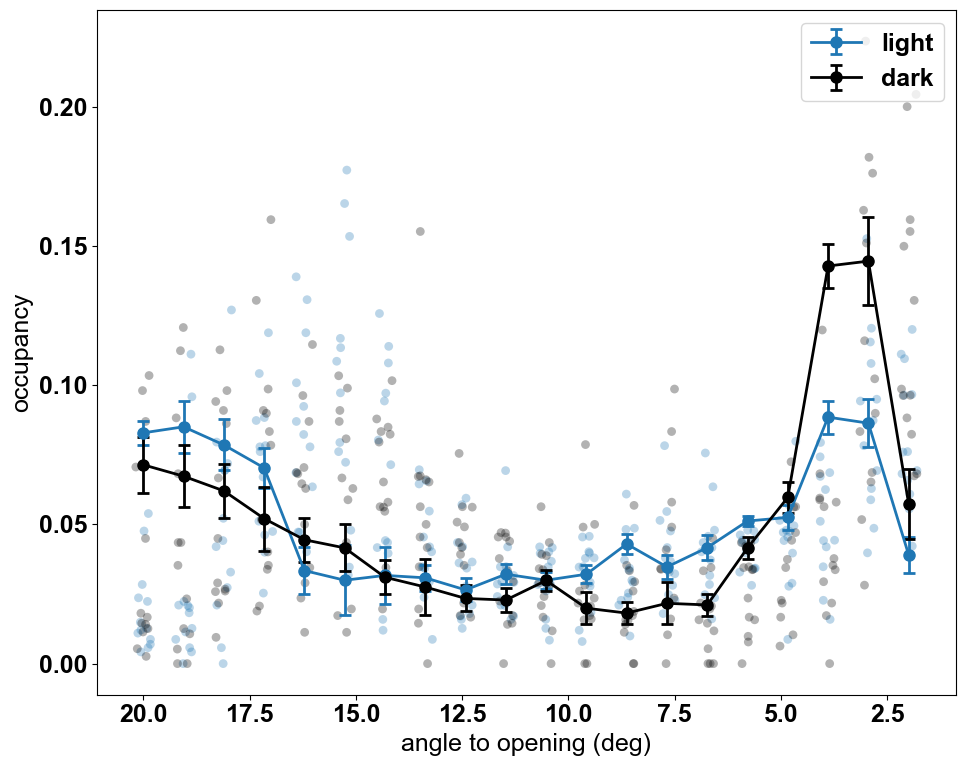

In [247]:
xnew = np.linspace(2, 20, 20)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = flatten_list_of_arrays(light.distances_at_head_turns.to_numpy())
light_dist = light_dist[~np.isnan(light_dist)]
light_dist = light_dist[np.where((light_dist >0))]
light_dist = light_dist[np.where((light_dist <=20))]
light_counts, light_bins = np.histogram(light_dist,bins=20)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.distances_at_head_turns.to_numpy())
    ani_light_dists = ani_light_dists[~np.isnan(ani_light_dists)]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >0))]
    counts, bins = np.histogram(ani_light_dists,bins=20)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(len(light_prob))  # Changed to SEM

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.distances_at_head_turns.to_numpy())
dark_dist = dark_dist[~np.isnan(dark_dist)]
dark_dist = dark_dist[np.where((dark_dist >0))]
dark_dist = dark_dist[np.where((dark_dist <=20))]
dark_counts, dark_bins = np.histogram(dark_dist,bins=20)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.distances_at_head_turns.to_numpy())
    ani_dark_dists = ani_dark_dists[~np.isnan(ani_dark_dists)]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >0))]
    counts, bins = np.histogram(ani_dark_dists,bins=20)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(len(dark_prob))  # Changed to SEM

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (now using SEM)
ax.errorbar(xnew, light_hist, yerr=light_sem,  # Changed to light_sem
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,  # Changed to dark_sem
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_ylabel('occupancy', fontsize=18)
ax.set_xlabel('angle to opening (deg)', fontsize=18)
ax.invert_xaxis()

# Legend
ax.legend(loc='upper right', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

(array([238., 535., 414., 175.,  59.,  43.,  14.,  17.,  20.,  11.]),
 array([ 191.56823973,  291.62202231,  391.67580488,  491.72958746,
         591.78337004,  691.83715262,  791.89093519,  891.94471777,
         991.99850035, 1092.05228293, 1192.1060655 ]),
 <BarContainer object of 10 artists>)

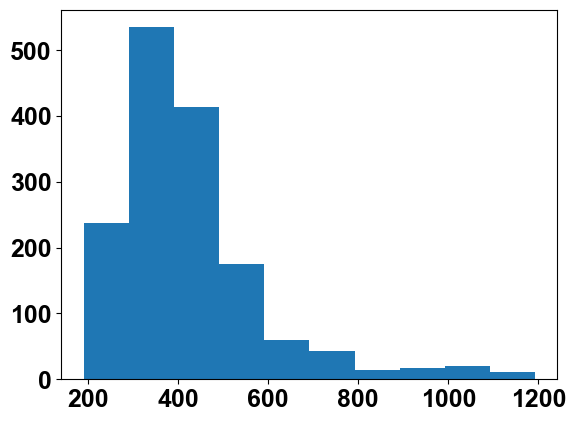

In [248]:
plt.hist(light.head_turn_velocity*60)

In [249]:
dark.num_turn

8884      6.0
8931     14.0
8933      2.0
8959      4.0
8967      3.0
         ... 
14456     3.0
14459     2.0
14479     4.0
14481     2.0
14523     3.0
Name: num_turn, Length: 1348, dtype: float64

In [190]:
test = light.sample(1)

In [207]:
test.num_turn

8121    0.0
Name: num_turn, dtype: float64

In [198]:
test.obstacle_ind

8121    32.0
Name: obstacle_ind, dtype: float64

In [208]:
peaks, prop = find_peaks(np.abs(test.head_angle_velocity.to_numpy()[0][:int(test.obstacle_ind.to_numpy()[0])]), width=2,height=(4,20),distance=10)

In [209]:
peaks

array([18], dtype=int64)

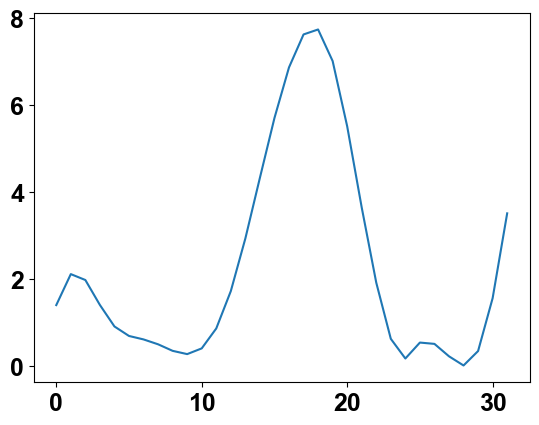

In [203]:
plt.plot(np.abs(test.head_angle_velocity.to_numpy()[0][:int(test.obstacle_ind.to_numpy()[0])]))

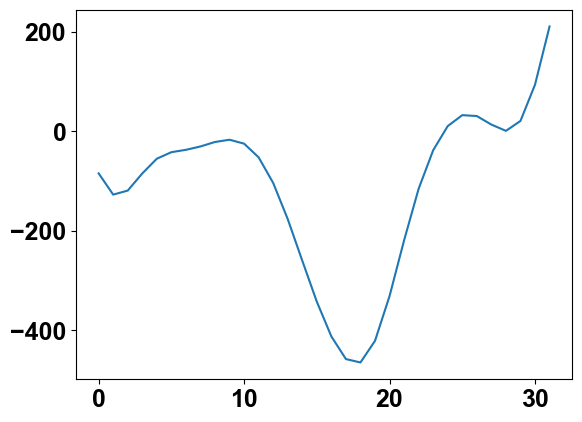

In [204]:
plt.plot(test.head_angle_velocity.to_numpy()[0][:int(test.obstacle_ind.to_numpy()[0])]*60)

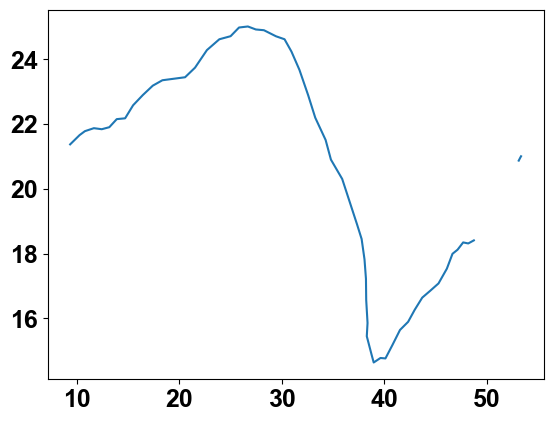

In [205]:
plt.plot(test.nose_x_cm.to_numpy()[0],test.nose_y_cm.to_numpy()[0])

In [173]:
light

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,indexs_of_head_turn,head_turn_indexs,before_head_turn_indexs,after_head_turn_indexs,angle_after_head_turn,angle_before_head_turn,head_turn_velocity,angles_at_head_turns,distances_at_head_turns,angles_at_head_turns_ends
8,8,48098.019340,48102.816128,"[48098.031385, 48098.048576, 48098.06464, 4809...","[[3308, 3309, 3310, 3311, 3312, 3313, 3314, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9629516601562, 650.8632202148438, 650.746...","[252.6468963623047, 251.91566467285156, 251.48...","[656.01318359375, 656.386474609375, 656.445373...",...,"[101, 104, 111]","[104, 132]","[101, 129]","[111, 141]",21.014839,68.444419,4.699180,[10.179569813810865],[1.8804369365781402],[3.7884585185741315]
17,17,48338.593881,48344.042022,"[48338.598041, 48338.614617, 48338.631424, 483...","[[17737, 17738, 17739, 17740, 17741, 17742, 17...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.9925537109375, 652.1788330078125, 652.823...","[254.21148681640625, 254.0948028564453, 254.07...","[656.2599487304688, 657.4254150390625, 658.723...",...,[nan],[nan],[nan],[nan],NaN,NaN,NaN,[nan],[nan],[nan]
24,24,48420.115289,48424.506713,"[48420.126092, 48420.143462, 48420.159539, 484...","[[22627, 22628, 22629, 22630, 22631, 22632, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6133422851562, 648.2860107421875, 648.863...","[258.9119873046875, 258.0534973144531, 257.625...","[656.2706298828125, 656.6029052734375, 656.868...",...,"[48, 51, 54]","[9, 40, 51, 61]","[6, 37, 48, 58]","[12, 43, 54, 64]",8.090993,64.665816,9.321765,"[45.577345895546785, 37.5903746436992, 3.77264...","[19.126954831503788, 6.2272710475092765, 2.441...","[27.188639381374767, 61.16532744737856, 14.880..."
27,27,48451.833305,48459.674124,"[48451.837196, 48451.85399, 48451.870681, 4845...","[[24529, 24530, 24531, 24532, 24533, 24534, 24...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6234741210938, 647.111083984375, 647.8052...","[258.09979248046875, 256.70001220703125, 256.1...","[653.6805419921875, 654.243408203125, 654.8812...",...,"[175, 179, 183]","[146, 179]","[143, 175]","[150, 183]",20.829883,65.492813,5.766666,[64.36320042000398],[22.825084479564573],[53.688582155444315]
29,29,48467.768192,48473.544102,"[48467.77591, 48467.792857, 48467.810598, 4846...","[[25485, 25486, 25487, 25488, 25489, 25490, 25...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.9254150390625, 652.91552734375, 653.34338...","[251.62893676757812, 252.2069091796875, 252.18...","[655.7667236328125, 656.9116821289062, 658.112...",...,"[179, 180, 182]","[23, 180, 205]","[19, 179, 204]","[29, 182, 206]",33.735538,33.807077,16.831029,"[67.75946009147836, 25.765737309484244]","[22.689007941167716, 2.311305803187799]","[34.78286736958878, 26.026518875201578]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8809,8809,53682.691097,53684.452428,"[53682.695372, 53682.713523, 53682.728844, 536...","[9889, 9890, 9891, 9892, 9893, 9894, 9895, 989...","[112.17072296142578, 112.42405700683594, 112.5...","[277.1304931640625, 277.2672119140625, 277.129...","[129.66957092285156, 127.5576400756836, 125.69...","[274.0078125, 274.1982116699219, 272.819396972...","[119.23519897460938, 117.94373321533203, 119.5...",...,[nan],[nan],[nan],[nan],NaN,NaN,NaN,[nan],[nan],[nan]
8827,8827,53737.922483,53740.560204,"[53737.931635, 53737.948006, 53737.964556, 537...","[13202, 13203, 13204, 13205, 13206, 13207, 132...","[112.039794921875, 112.21412658691406, 112.549...","[276.7937316894531, 276.2401428222656, 275.822...","[129.1151885986328, 127.08348846435547, 126.63..

In [ ]:
light.head_turn_velocity.to_numpy()

array([4.69918027,        nan, 9.32176479, ...,        nan,        nan,
              nan])

In [162]:
np.isnan(light.head_turn_velocity.to_numpy()).sum()

1054

(array([0.00037001, 0.00148005, 0.00228443, 0.00310489, 0.00299228,
        0.0027027 , 0.00185006, 0.00101351, 0.00061133, 0.0002574 ]),
 array([200., 260., 320., 380., 440., 500., 560., 620., 680., 740., 800.]),
 <BarContainer object of 10 artists>)

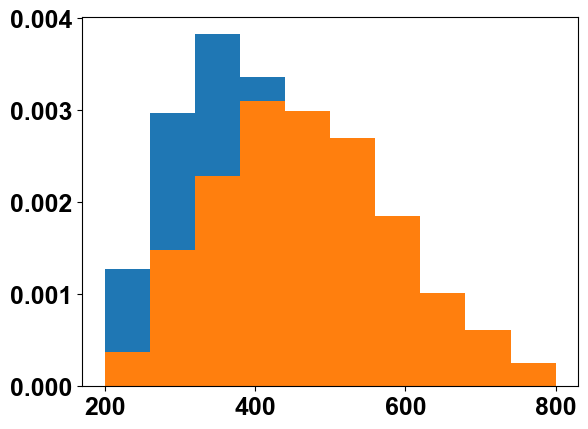

In [255]:
plt.hist(light.head_turn_velocity*60,density=True,range=(200,800))
plt.hist(dark.head_turn_velocity*60,density=True,range=(200,800))

In [251]:
light.head_turn_velocity.mean()*60

425.0109802067108

In [252]:
dark.head_turn_velocity.mean()*60

510.54222047893705

In [137]:
dark_dist.shape[0]/len(dark)

1.045994065281899

In [138]:
light_dist.shape[0]/len(light)

0.7328800388538125

(array([345., 346., 107.,  68.,  85.,  79., 100., 147., 195., 237.]),
 array([ 0.10234069,  2.09158608,  4.08083148,  6.07007688,  8.05932227,
        10.04856767, 12.03781307, 14.02705847, 16.01630386, 18.00554926,
        19.99479466]),
 <BarContainer object of 10 artists>)

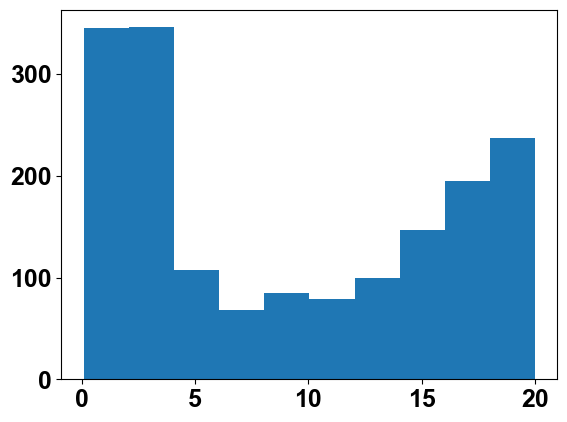

In [253]:
plt.hist(dark_dist)

(array([289., 325., 214., 179., 143., 135., 144., 146., 343., 387.]),
 array([ 0.0206409 ,  2.01798362,  4.01532635,  6.01266908,  8.01001181,
        10.00735454, 12.00469726, 14.00203999, 15.99938272, 17.99672545,
        19.99406818]),
 <BarContainer object of 10 artists>)

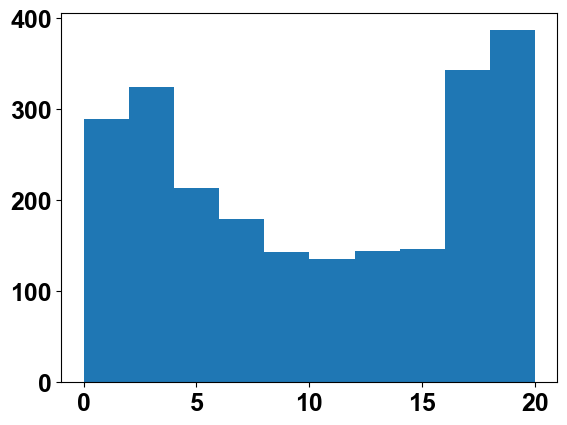

In [254]:
plt.hist(light_dist)

In [115]:
light_scatter[0][1].shape

(10,)

light.distance_at_head_turn.hist()

In [90]:
light.distance_at_head_turn.median()

7.724330643721494

In [95]:
light.angle_after_head_turn.median()

25.481593923439995

In [ ]:
            df.at[ind,'angle_after_head_turn'] =np.asarray([np.nan]) 


In [72]:
np.median(ani_light_dists)

7.91913615976263

In [79]:
light_dist.mean()

45.37786928038147

In [80]:
dark_dist.mean()

49.934694084885095

In [82]:
np.median(light_dist)

41.697731974718806

In [74]:
long.shape

(3407, 277)

In [75]:
long

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,distance_before_head_turn,indexs_of_head_turn,head_turn_indexs,before_head_turn_indexs,after_head_turn_indexs,angle_after_head_turn,angle_before_head_turn,head_turn_velocity,angles_at_head_turns,angles_at_head_turns_ends
8,8,48098.019340,48102.816128,"[48098.031385, 48098.048576, 48098.06464, 4809...","[[3308, 3309, 3310, 3311, 3312, 3313, 3314, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9629516601562, 650.8632202148438, 650.746...","[252.6468963623047, 251.91566467285156, 251.48...","[656.01318359375, 656.386474609375, 656.445373...",...,1.302126,"[101, 104, 111]","[104, 132]","[101, 129]","[111, 141]",21.014839,68.444419,4.699180,[10.179569813810865],[3.7884585185741315]
17,17,48338.593881,48344.042022,"[48338.598041, 48338.614617, 48338.631424, 483...","[[17737, 17738, 17739, 17740, 17741, 17742, 17...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.9925537109375, 652.1788330078125, 652.823...","[254.21148681640625, 254.0948028564453, 254.07...","[656.2599487304688, 657.4254150390625, 658.723...",...,NaN,[nan],[nan],[nan],[nan],NaN,NaN,NaN,[nan],[nan]
24,24,48420.115289,48424.506713,"[48420.126092, 48420.143462, 48420.159539, 484...","[[22627, 22628, 22629, 22630, 22631, 22632, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6133422851562, 648.2860107421875, 648.863...","[258.9119873046875, 258.0534973144531, 257.625...","[656.2706298828125, 656.6029052734375, 656.868...",...,4.652525,"[48, 51, 54]","[9, 40, 51, 61]","[6, 37, 48, 58]","[12, 43, 54, 64]",8.090993,64.665816,9.321765,"[45.577345895546785, 37.5903746436992, 3.77264...","[27.188639381374767, 61.16532744737856, 14.880..."
27,27,48451.833305,48459.674124,"[48451.837196, 48451.85399, 48451.870681, 4845...","[[24529, 24530, 24531, 24532, 24533, 24534, 24...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6234741210938, 647.111083984375, 647.8052...","[258.09979248046875, 256.70001220703125, 256.1...","[653.6805419921875, 654.243408203125, 654.8812...",...,9.925950,"[175, 179, 183]","[146, 179]","[143, 175]","[150, 183]",20.829883,65.492813,5.766666,[64.36320042000398],[53.688582155444315]
29,29,48467.768192,48473.544102,"[48467.77591, 48467.792857, 48467.810598, 4846...","[[25485, 25486, 25487, 25488, 25489, 25490, 25...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.9254150390625, 652.91552734375, 653.34338...","[251.62893676757812, 252.2069091796875, 252.18...","[655.7667236328125, 656.9116821289062, 658.112...",...,3.716643,"[179, 180, 182]","[23, 180, 205]","[19, 179, 204]","[29, 182, 206]",33.735538,33.807077,16.831029,"[67.75946009147836, 25.765737309484244]","[34.78286736958878, 26.026518875201578]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14456,14456,58284.241510,58286.769433,"[58284.250803, 58284.267686, 58284.284518, 582...","[10663, 10664, 10665, 10666, 10667, 10668, 106...","[87.75959014892578, 86.99541473388672, 86.5253...","[260.9606018066406, 261.192138671875, 260.8676...","[101.29974365234375, 99.75284576416016, 98.431...","[256.0437316894531, 256.8573913574219, 257.122...","[94.1467056274414, 93.94309997558594, 93.60278...",...,1.245620,"[25, 28, 32]","[28, 40]","[25, 39]","[32, 41]",27.423604,79.641270,7.004480,[3.348101301207836],[1.2407274419492227]
14459,14459,58310.359923,58312.854592,"[58310.360256, 58310.376601, 58310.39406, 5831...","[12229, 12230, 12231, 12232, 12233, 12234, 122...","[86.841064453125, 86.9388427734375, 86.4898529...","[257.9836730957031, 258.0146179199219, 257.881...","[104.91130065917969, 103.79759979248047, 102.6...","[253.5960235595703,